In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.dates as mdates

# Assigns colourscheme for plots
c_aowb = '#e87c89'
c_owb = '#31587f'

In [2]:
######################################### FILE PATHS #########################################

CSV_file_for_L4_chloro = "/gws/pw/j25/rep/dapa/obs_for_oscar/L4_data/chlorophyll_a_wco_19922022_dataset_sheet1.csv"

CSV_file_for_L4_nutrients ='/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/L4_analysis/L4_nutrients_obs.csv'

owb_idir = '/gws/pw/j25/rep/omerrett/OWB/Analysis'
aowb_idir = '/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis'

mesh_mask = "/home/users/omerrett/mesh_mask.nc"



In [3]:
######################################### CHLOROPHYLL DATA #########################################

# Import L4 Chlorophyll data from csv file
L4_chlor = pd.read_csv(CSV_file_for_L4_chloro,
                       na_values=-99
                      )

L4_chlor['date'] = pd.to_datetime(L4_chlor[['Year', 'Month', 'Day']])
L4_chlor = L4_chlor[L4_chlor['Year'] == 2018].sort_values('date')

L4_chlor_surface = L4_chlor[L4_chlor[' Depth (metres)'] == 0].sort_values('date')

# Import AOWB and OWB model data from L4_chloro_model_data.py
AOWB = xr.open_dataset(f"{aowb_idir}/L4_analysis/L4_Chlorophyll_AOWB.nc")
OWB = xr.open_dataset(f"{aowb_idir}/L4_analysis/L4_Chlorophyll_AOWB.nc")

In [4]:
######################################### TEMPERATURE DATA #########################################


# Import L4 temperature data from netcdf file
L4_temp = xr.open_dataset('/gws/pw/j25/rep/dapa/obs_for_oscar/L4_data/L4_temp.nc')
L4_2018 = L4_temp.where(L4_temp.time_ref.dt.year == 2018, drop=True)
L4_surface_temp = L4_2018.where(L4_2018.depth_ref == 2.0, drop=True)
L4_surface_temp = L4_surface_temp.sortby('time_ref')

# Import AOWB and OWB model data from L4_temp_model_data.py
OWB_temp = xr.open_dataset(f"{owb_idir}/L4_analysis/L4_temperature_OWB.nc")
AOWB_temp = xr.open_dataset(f"{aowb_idir}/L4_analysis/L4_temperature_AOWB.nc")

# Assigns physical depth (m) to temperature data based of the domain mask
grd = xr.open_dataset(mesh_mask).isel(t=0).rename({'z':'depthw'})

reg_depths = {}


xsl = slice(725,727)
ysl = slice(374,375)
e3t = grd.e3t_0.isel(y=ysl,x=xsl).mean(['x','y']) 
depth = -1*grd.gdept_0.isel(x=xsl,y=ysl).mean(['x','y']).values
reg_depths = depth

OWB_temp = OWB_temp.assign_coords(
            deptht=reg_depths
        )

AOWB_temp = AOWB_temp.assign_coords(
            deptht=reg_depths
        )



In [5]:
######################################### NUTRIENT DATA #########################################

# Import AOWB and OWB model data from L4_nutrient_model_data.py
AOWB_N3_n = xr.open_dataset(f"{aowb_idir}/L4_analysis/L4_Nutrients_AOWB.nc")
OWB_N3_n = xr.open_dataset(f"{owb_idir}/L4_analysis/L4_Nutrients_OWB.nc")

# Import L4 nutrient data from csv file
L4_nutrients = pd.read_csv(CSV_file_for_L4_nutrients,
                           skiprows=[1], 
                           na_values=['N', '<', ' '])

L4_nutrients = L4_nutrients.loc[:, ~L4_nutrients.columns.str.contains('^Unnamed')]
L4_nutrients['Date'] = pd.to_datetime(L4_nutrients['Date'], dayfirst=True)
L4_nutrients['NITRATE'] = L4_nutrients['NITRATE+NIT'] - L4_nutrients['NITRITE'].fillna(0)

L4_nutrients = L4_nutrients.groupby(['Date', 'Depth']).mean(numeric_only=True).reset_index()

L4_2018_surface = L4_nutrients[(L4_nutrients['Depth'] == 0)]

L4_2018_surface = L4_2018_surface.sort_values('Date')

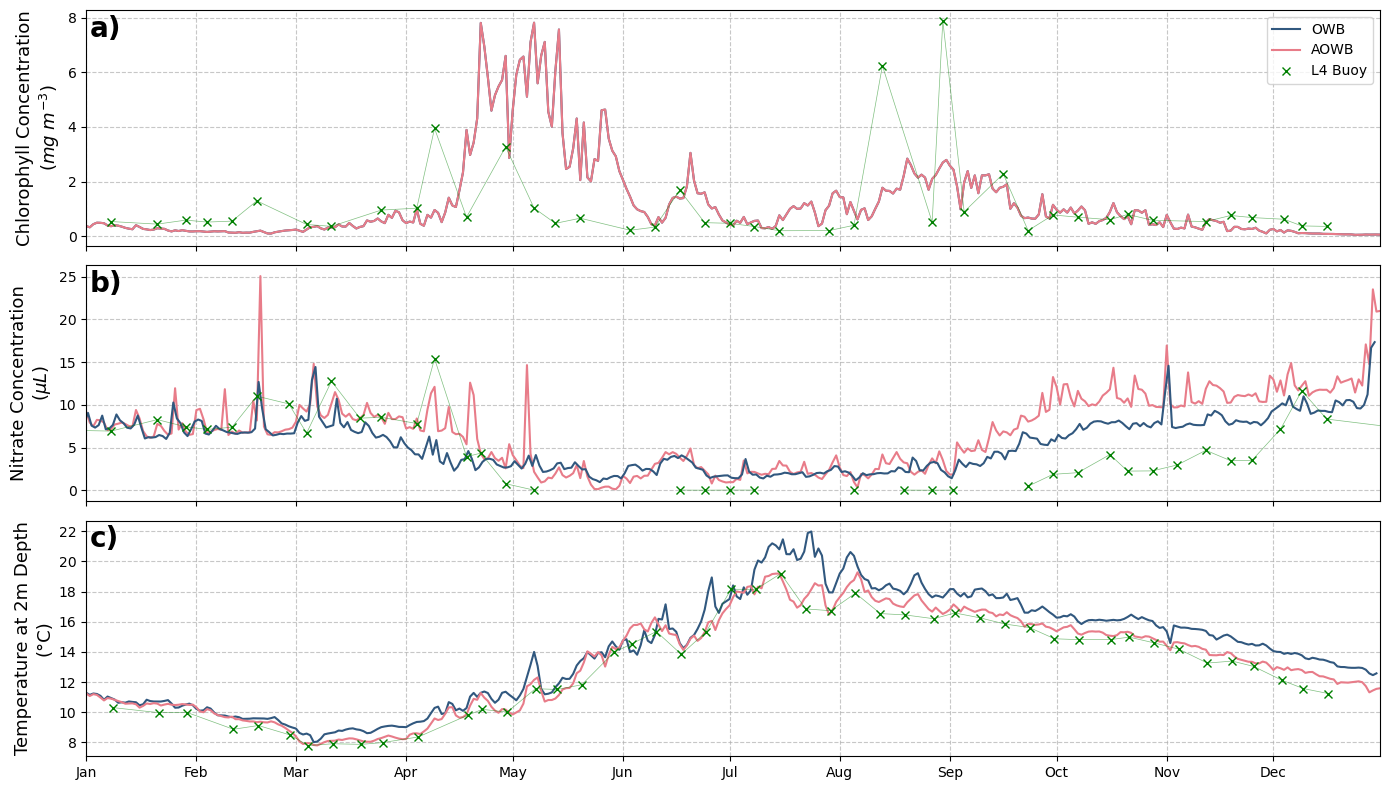

In [6]:
# Plots the 3 timeseries

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fontsize_axis = 13

fig, (ax1, ax3, ax2) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)


# Plots chlorophyll timeseries for models and L4 data
ax1.plot(OWB['cell_375_725'].time_counter, OWB['cell_375_725'].values, 
         label='OWB', color=c_owb)
ax1.plot(AOWB['cell_375_725'].time_counter, AOWB['cell_375_725'].values, 
         label='AOWB', color=c_aowb)
ax1.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], 
         linewidth=0.5, color='green', alpha=0.5)
ax1.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], 
         'x', color='green', label='L4 Buoy')

ax1.set_ylabel('Chlorophyll Concentration\n($mg$ $m^{-3}$)',fontsize=fontsize_axis)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# Plots temperature timeseries for models and L4 data
ax2.plot(OWB_temp['2x2'].isel(deptht=1).time_counter, OWB_temp['2x2'].isel(deptht=1).values, 
         label='OWB', color=c_owb)
ax2.plot(AOWB_temp['2x2'].isel(deptht=1).time_counter, AOWB_temp['2x2'].isel(deptht=1).values, 
         label='AOWB', color=c_aowb)
ax2.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         linewidth=0.5, alpha=0.5, color='green')
ax2.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         'x', label='L4 Buoy', color='green')

ax2.set_ylabel('Temperature at 2m Depth\n(°C)',fontsize=fontsize_axis)
ax2.grid(True, linestyle='--', alpha=0.7)

# Plots nutrient timeseries for models and L4 data
ax3.plot(AOWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, AOWB_N3_n['2x2'].isel(deptht = 1).values, label = 'AOWB',color = c_aowb)
ax3.plot(OWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, OWB_N3_n['2x2'].isel(deptht = 1).values, label = 'OWB',color = c_owb)

ax3.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'],
         linewidth = 0.5, alpha = 0.5, color='green')
ax3.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'],
         'x', label='L4 Buoy', color='green')

ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_ylabel('Nitrate Concentration\n($\mu L$)',fontsize=fontsize_axis)

# Formatting dates
ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax3.tick_params(axis='x', labelsize=14)

time_min = OWB['cell_375_725'].time_counter.min().values
time_max = OWB['cell_375_725'].time_counter.max().values
ax2.set_xlim(time_min, time_max)

# Labels axes
label_style = dict(fontsize=20, fontweight='bold', va='top', ha='left')
ax1.text(0.003, 0.98, 'a)', transform=ax1.transAxes, **label_style)
ax3.text(0.003, 0.98, 'b)', transform=ax3.transAxes, **label_style)
ax2.text(0.003, 0.98, 'c)', transform=ax2.transAxes, **label_style)

plt.tight_layout()
plt.savefig('L4_Chl_N3_n_Temp_Comparison_2018.png', dpi=600, bbox_inches='tight')
plt.show()